# (연구) importance of data (HST old example) 
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [논문연구]

In [1]:
# hide
import rpy2 
%load_ext rpy2.ipython

In [2]:
%%R 
hst1d<-function(f,tau,b=sd(f)*0.01,prob=c(1/3,1/3,1/3)) # prob=c(l,c,r)
{
  lprob<-prob[1]
  cprob<-prob[2]
  rprob<-prob[3]
  len<-length(f)
  hstresult<-rep(0,len*tau); dim(hstresult)<-c(len,tau)
  hlen<-round(len/2)
  oldf<-f
  f<-c(f[hlen:1],f,f[len:(len-hlen+1)])
  
  ls<-landshape(f)
  f_before<-f
  f_after<-f*0
  L<-length(f)

  for(i in 1:tau)
  {
    minindex<-which(ls=="minimum")
    maxindex<-which(ls=="maximum")
    incindex<-which(ls=="increasing")
    decindex<-which(ls=="decreasing")
    flatindex<-which(ls=="flat")
    epsilon<-runif(1)*b
    f_after[minindex]<-f_before[minindex]+epsilon+epsilon*lprob+epsilon*rprob
    f_after[maxindex]<-f_before[maxindex]+epsilon*cprob
    f_after[incindex]<-f_before[incindex]+epsilon*(cprob+rprob)+epsilon*(lprob)
    f_after[decindex]<-f_before[decindex]+epsilon*(cprob+lprob)+epsilon*(rprob)
    f_after[flatindex]<-f_before[flatindex]+epsilon*cprob+epsilon*rprob*0.5+epsilon*lprob*0.5
    ls<-landshape(f_after)
    f_before<-f_after
    hstresult[,i]<-f_after[(hlen+1):(L-hlen)]
  }
  cbind(oldf,hstresult)
}

landshape<-function(f)
{
  len<-length(f)
  ls<-f*0
  ls[c(1,len)]<-"flat"
  for(i in 2:(len-1))
  {
    if((f[i]>f[i-1])&(f[i]<f[i+1])) ls[i]<-"increasing"
    else if((f[i]<f[i-1])&(f[i]>f[i+1])) ls[i]<-"decreasing"
    else if(mean(c(f[i-1],f[i+1]))<f[i]) ls[i]<-"maximum"
    else if(mean(c(f[i-1],f[i+1]))>f[i]) ls[i]<-"minimum"
    else ls[i]<-"flat"
  }
  ls
}

In [3]:
%%R 
## define the function 
f<-c(rnorm(512,0,0.5),rnorm(512,5,0.5))

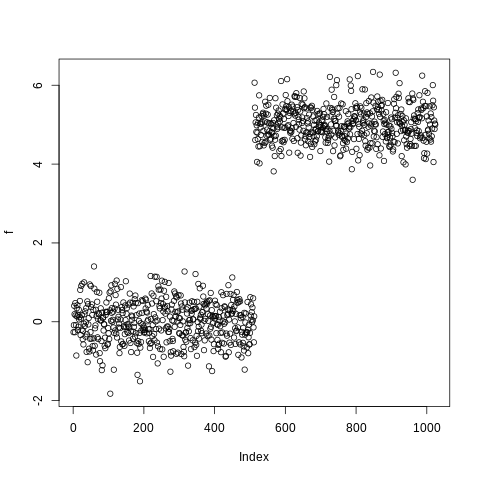

In [5]:
%%R 
plot(f)

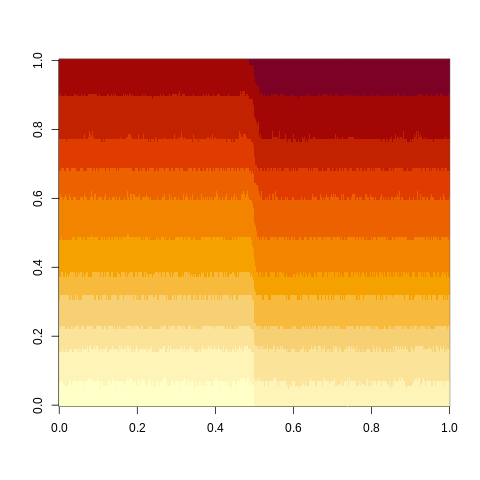

In [6]:
%%R 
hstrlst_once<-hst1d(f,tau=120,b=1)
image(hstrlst_once)

In [7]:
%%R 
library(tidyverse)
args <- tribble(
  ~funtion,      ~params,
  "hst1d", list(f=f,tau=120,b=1,prob=c(0.5,0,0,5)),
  "hst1d", list(f=f,tau=120,b=1,prob=c(0.5,0,0.5)),
  "hst1d", list(f=f,tau=120,b=1,prob=c(0.5,0,0.5))
)
print(args)
hstrslt_ <- args %>% mutate(simrslt=invoke_map(funtion,params))

R[write to console]: ── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

R[write to console]: ✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.2     ✔ dplyr   1.0.7
✔ tidyr   1.1.3     ✔ stringr 1.4.0
✔ readr   1.4.0     ✔ forcats 0.5.1

R[write to console]: ── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()



# A tibble: 3 x 2
  funtion params          
  <chr>   <list>          
1 hst1d   <named list [4]>
2 hst1d   <named list [4]>
3 hst1d   <named list [4]>


In [9]:
%%R
hstrslt=(hstrslt_[[3]][[1]]+hstrslt_[[3]][[2]]+hstrslt_[[3]][[3]])/3

In [10]:
%%R
PCrslt<-princomp(hstrslt)

In [12]:
%%R
dist<-function(hstrslt)
{
  n<-dim(hstrslt)[1]
  distancematrix<-rep(0,n*n)
  dim(distancematrix)<-c(n,n)
  for(i in 1:n)
  {
    for(j in 1:n)
    {
      distancematrix[i,j]<-sum((hstrslt[i,]-hstrslt[j,])^2)
    }
  }
  distancematrix
}

In [13]:
%%R
impt<-function(distancematrix,radius)
{
  n<-dim(distancematrix)[1]
  imp<-rep(0,n)
  for(i in 1:n)
  {
    imp[i]<-1/(sum((distancematrix[i,]<radius)*1)/n)
  }
  imp
}


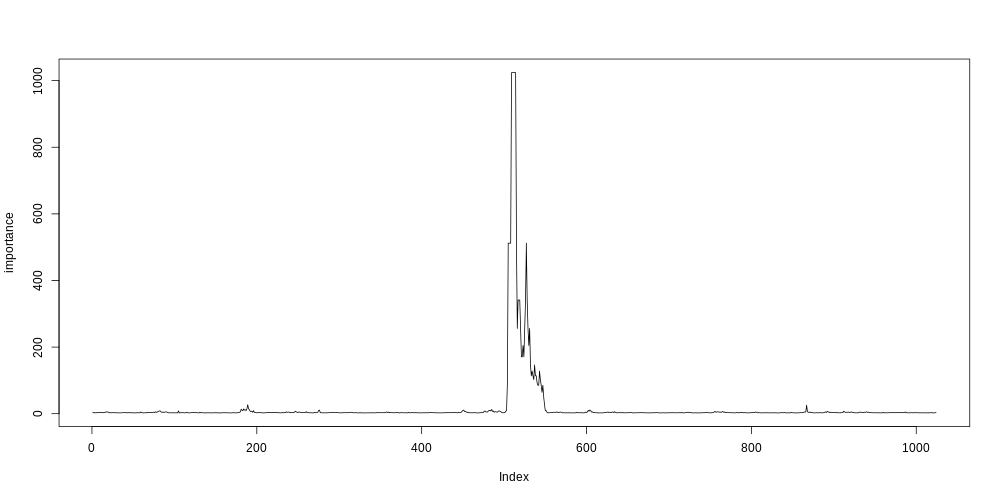

In [27]:
%%R -w 1000 -h 500 
distancematrix<-dist(hstrslt)
importance<-impt(distancematrix,radius=15)
plot(importance,type='l')

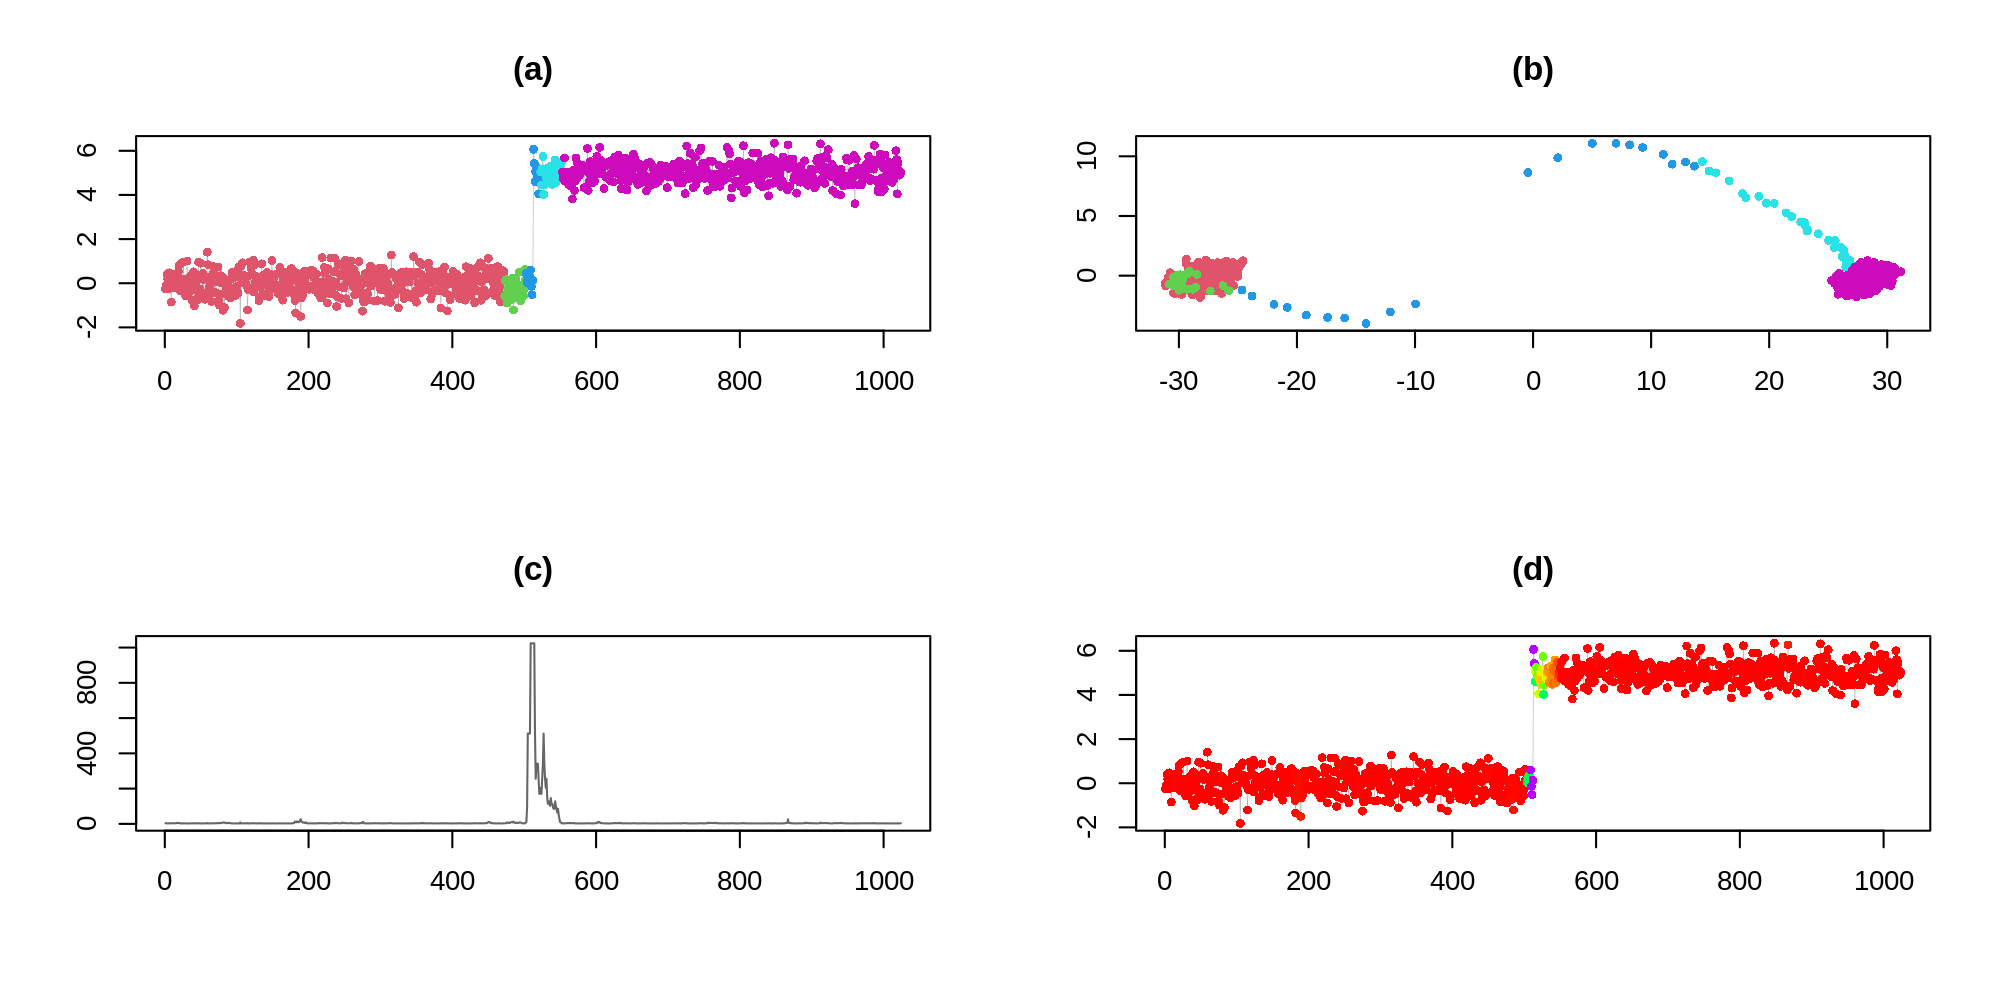

In [26]:
%%R -w 2000 -h 1000 -r 200
cex=0.5
rb<-rainbow(1001*1.3)

## temp variable for ploting 

xrange1<-1:472
xrange2<-473:502
xrange3<-503:522
xrange4<-523:552
xrange5<-553:1024

## plotting 2 
### snow_ex3_fig1
par(mfrow=c(2,2))
plot(f,col="gray60",cex=cex,main="(a)",xlab="",ylab="")
lines(f,lwd=0.3,col="gray70")
points(xrange1,f[xrange1],col=2,cex=0.7,pch=16)
points(xrange2,f[xrange2],col=3,cex=0.7,pch=16)
points(xrange3,f[xrange3],col=4,cex=0.7,pch=16)
points(xrange4,f[xrange4],col=5,cex=0.7,pch=16)
points(xrange5,f[xrange5],col=6,cex=0.7,pch=16)
### snow_ex3_fig2
plot(PCrslt$scores[,1], PCrslt$scores[,2],col="gray60",cex=cex,main="(b)",xlab="",ylab="")
points(PCrslt$scores[xrange1,1], PCrslt$scores[xrange1,2],col=2,cex=0.7,pch=16)
points(PCrslt$scores[xrange2,1], PCrslt$scores[xrange2,2],col=3,cex=0.7,pch=16)
points(PCrslt$scores[xrange3,1], PCrslt$scores[xrange3,2],col=4,cex=0.7,pch=16)
points(PCrslt$scores[xrange4,1], PCrslt$scores[xrange4,2],col=5,cex=0.7,pch=16)
points(PCrslt$scores[xrange5,1], PCrslt$scores[xrange5,2],col=6,cex=0.7,pch=16)
### snow_ex3_fig3
plot(importance,cex=cex,main="(c)",xlab="",ylab="",type='l',col="gray40")

### snow_ex3_fig4
plot(f,col="gray60",cex=0.1,main="(d)",xlab="",ylab="")
lines(f,lwd=0.3,col="gray70")
points(f,col=rb[importance],cex=0.7,pch=16)
points(f,col=rb[importance],cex=0.7,pch=16)
par(mfrow=c(1,1))